In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

In [2]:
data ="./archive"

In [3]:
wav_files = []

for root, dirs, files in os.walk(data):

    for file in files:

        if file.endswith(".wav"):

            wav_files.append(os.path.join(root, file))

print("Total wav files:", len(wav_files))

print(wav_files[:5])

Total wav files: 2880
['./archive\\Actor_01\\03-01-01-01-01-01-01.wav', './archive\\Actor_01\\03-01-01-01-01-02-01.wav', './archive\\Actor_01\\03-01-01-01-02-01-01.wav', './archive\\Actor_01\\03-01-01-01-02-02-01.wav', './archive\\Actor_01\\03-01-02-01-01-01-01.wav']


In [4]:
modality = {
    "01": "full-AV",
    "02": "video-only",
    "03": "audio-only"
}

vocal_channel = {
    "01": "speech",
    "02": "song"
}

emotion_m = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

emotional_intensity = {
    "01": "normal",
    "02": "strong"
}

statement = {
    "01": "Kids are talking by the door",
    "02": "Dogs are sitting by the door"
}

repetition = {
    "01": "1st repetition",
    "02": "2nd repetition"
}


In [5]:
def parse_ravdess_filename(path):
    file = os.path.basename(path)
    parts = file.replace(".wav", "").split("-")
    return {
        "Modality": modality[parts[0]],
        "Vocal channel": vocal_channel[parts[1]],
        "Emotion": emotion_m[parts[2]],
        "Emotional intensity": emotional_intensity[parts[3]],
        "Statement": statement[parts[4]],
        "Repetition": repetition[parts[5]],
        "Actor": parts[6]
    }

In [6]:
f1= wav_files[0]

In [7]:
print(f1)

./archive\Actor_01\03-01-01-01-01-01-01.wav


In [8]:
print(parse_ravdess_filename(f1))

{'Modality': 'audio-only', 'Vocal channel': 'speech', 'Emotion': 'neutral', 'Emotional intensity': 'normal', 'Statement': 'Kids are talking by the door', 'Repetition': '1st repetition', 'Actor': '01'}


In [9]:
decode = []

In [10]:
for file in wav_files:
    info = parse_ravdess_filename(file)
    decode.append(info)

In [11]:
df= pd.DataFrame(decode)

In [12]:
df.head()

,Modality,Vocal channel,Emotion,Emotional intensity,Statement,Repetition,Actor
0,audio-only,speech,neutral,normal,Kids are talking by the door,1st repetition,01
1,audio-only,speech,neutral,normal,Kids are talking by the door,2nd repetition,01
2,audio-only,speech,neutral,normal,Dogs are sitting by the door,1st repetition,01
3,audio-only,speech,neutral,normal,Dogs are sitting by the door,2nd repetition,01
4,audio-only,speech,calm,normal,Kids are talking by the door,1st repetition,01


In [13]:
emotions = df["Emotion"].value_counts()
print(emotions)

Emotion
calm         384
happy        384
sad          384
angry        384
disgust      384
fearful      384
surprised    384
neutral      192
Name: count, dtype: int64


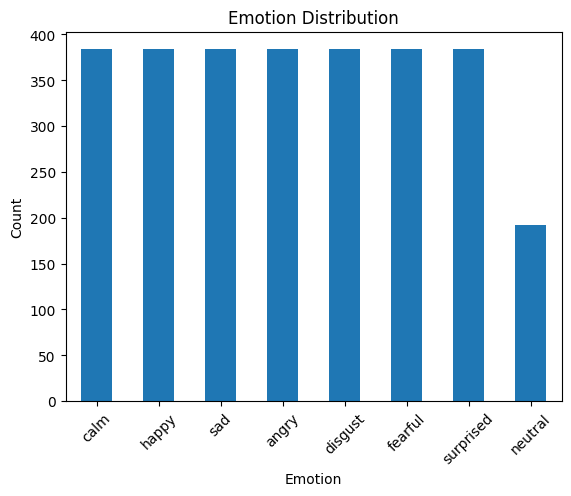

In [14]:
emotions.plot(kind="bar")

plt.title("Emotion Distribution")

plt.xlabel("Emotion")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [15]:
audio, sr = librosa.load(file, sr=None)

In [16]:
sr

48000

In [17]:
duration= []

In [18]:
for file in wav_files:
    audio, sr = librosa.load(file, sr=None)
    dur = len(audio) / sr
    duration.append(dur)

In [19]:
df1=pd.DataFrame(duration)

In [20]:
df1.head

<bound method NDFrame.head of              0
0     3.303292
1     3.336667
2     3.269917
3     3.169833
4     3.536854
...        ...
2875  3.403396
2876  3.937271
2877  3.970625
2878  3.670333
2879  3.636958

[2880 rows x 1 columns]>

In [21]:
mean_dur = np.mean(duration)

In [22]:
std_dur = np.std(duration)

In [23]:
mean_dur

np.float64(3.7006648148148145)

In [24]:
std_dur

np.float64(0.3365587103688152)

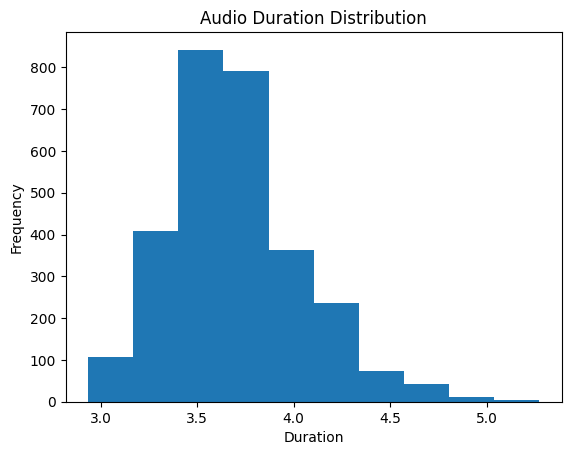

In [25]:
plt.hist(duration)
plt.title("Audio Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

In [26]:
happy= None
sad= None
angry = None

In [27]:
for file in wav_files:
    emotion1 = parse_ravdess_filename(file)["Emotion"]
    if emotion1== "happy" and happy== None:
        happy=file

    if emotion1== "sad" and sad== None:
        sad=file

    if emotion1== "angry" and angry == None:
        angry=file
     

In [28]:
happy

'./archive\\Actor_01\\03-01-03-01-01-01-01.wav'

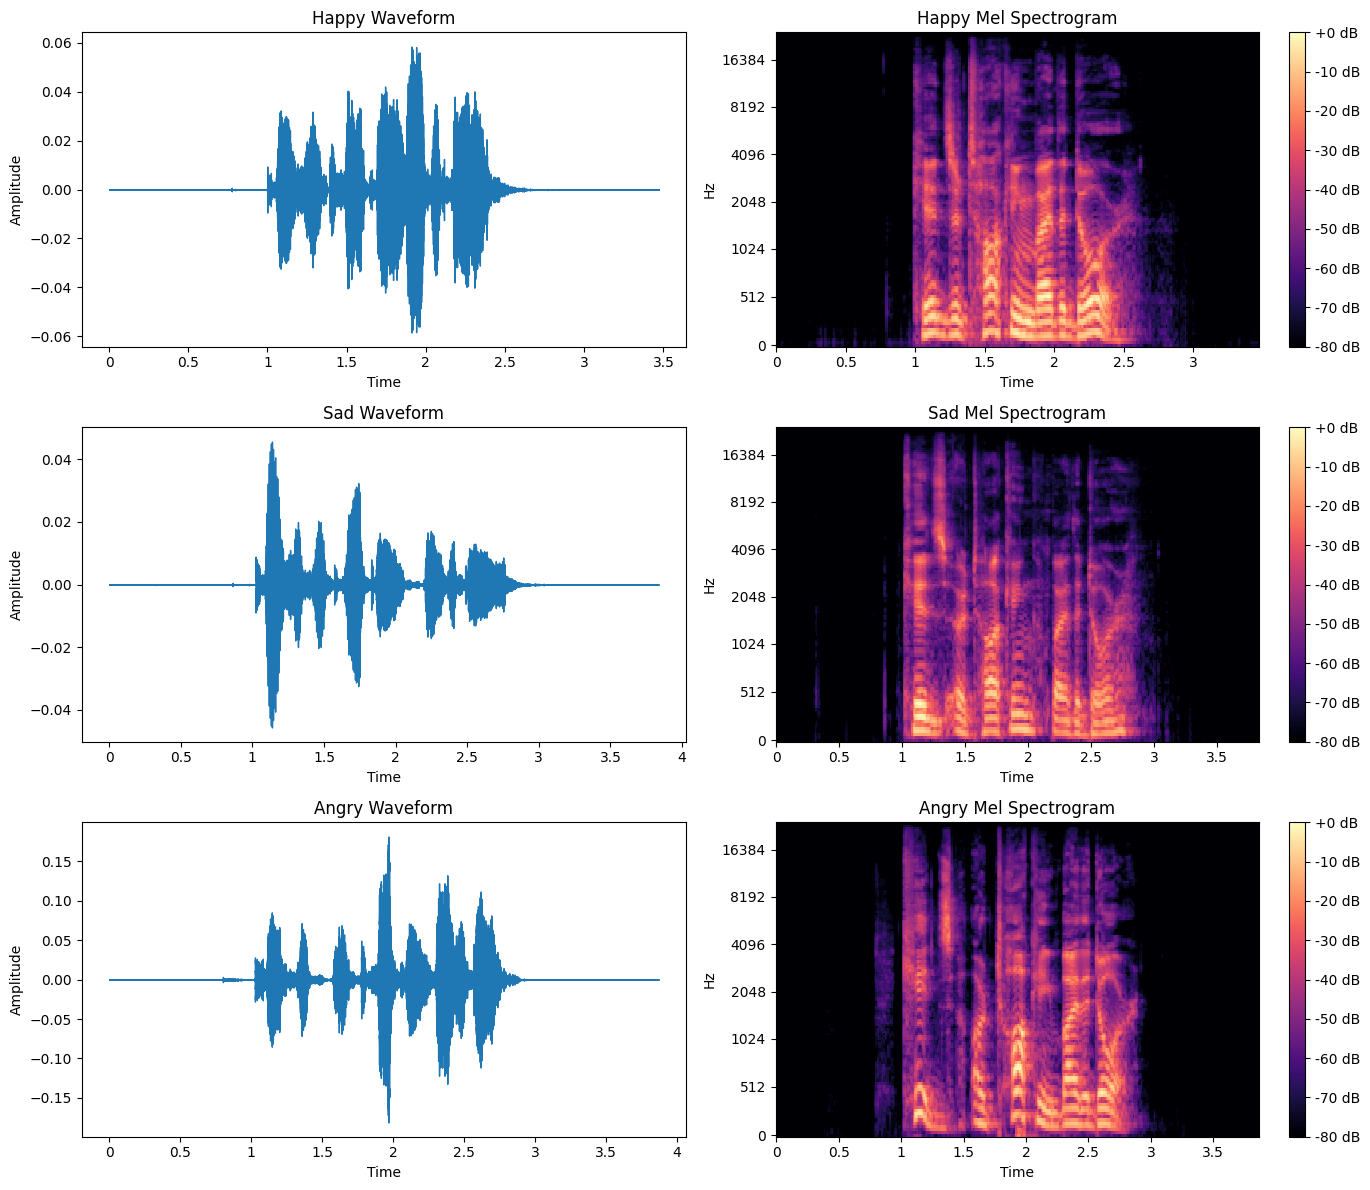

In [29]:
emotion_files = [
    ("happy", happy),
    ("sad", sad),
    ("angry", angry)
]

fig, axes = plt.subplots( 3, 2, figsize=(14, 12))


for i, (emotion, file) in enumerate(emotion_files):
    audio, sr = librosa.load( file, sr=None)
    librosa.display.waveshow( audio,sr=sr, ax=axes[i, 0] )
    axes[i, 0].set_title(f"{emotion.capitalize()} Waveform")
    axes[i, 0].set_xlabel("Time")
    axes[i, 0].set_ylabel("Amplitude")

    mel = librosa.feature.melspectrogram(y=audio, sr=sr )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title( f"{emotion.capitalize()} Mel Spectrogram")
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB' )

plt.tight_layout()
plt.show()

In [30]:
import opensmile

In [31]:
smile = opensmile . Smile (
 feature_set = opensmile . FeatureSet . eGeMAPSv02 ,
 feature_level = opensmile . FeatureLevel . Functionals ,
 )
features = smile . process_file (f1)
print ( features . shape ) # should be (1 , 88)
print ( features . columns . tolist () )

(1, 88)
['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0', 'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope', 'loudness_sma3_stddevFallingSlope', 'spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm', 'mfcc1_sma3_amean', 'mfcc1_sma3_stddevNorm', 'mfcc2_sma3_amean', 'mfcc2_sma3_stddevNorm', 'mfcc3_sma3_amean', 'mfcc3_sma3_stddevNorm', 'mfcc4_sma3_amean', 'mfcc4_

In [32]:
all_feat = []

for i, file in enumerate(wav_files):

    print(f"Processing {i+1}/{len(wav_files)}")

    feat = smile.process_file(file)

    feat["Emotion"] = parse_ravdess_filename(file)["Emotion"]

    all_feat.append(feat)

Processing 1/2880
Processing 2/2880
Processing 3/2880
Processing 4/2880
Processing 5/2880
Processing 6/2880
Processing 7/2880
Processing 8/2880
Processing 9/2880
Processing 10/2880
Processing 11/2880
Processing 12/2880
Processing 13/2880
Processing 14/2880
Processing 15/2880
Processing 16/2880
Processing 17/2880
Processing 18/2880
Processing 19/2880
Processing 20/2880
Processing 21/2880
Processing 22/2880
Processing 23/2880
Processing 24/2880
Processing 25/2880
Processing 26/2880
Processing 27/2880
Processing 28/2880
Processing 29/2880
Processing 30/2880
Processing 31/2880
Processing 32/2880
Processing 33/2880
Processing 34/2880
Processing 35/2880
Processing 36/2880
Processing 37/2880
Processing 38/2880
Processing 39/2880
Processing 40/2880
Processing 41/2880
Processing 42/2880
Processing 43/2880
Processing 44/2880
Processing 45/2880
Processing 46/2880
Processing 47/2880
Processing 48/2880
Processing 49/2880
Processing 50/2880
Processing 51/2880
Processing 52/2880
Processing 53/2880
Pr

In [33]:
feat["Emotion"]

file                                                                   start   end                      
./archive\audio_speech_actors_01-24\Actor_24\03-01-08-02-02-02-24.wav  0 days  0 days 00:00:03.636958333    surprised
Name: Emotion, dtype: object

In [34]:
df2 = pd.concat(all_feat)

In [35]:
df2.head()

,,,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,Emotion
file,start,end,,,,,,,,,,,,,,,,,,,,,
./archive\Actor_01\03-01-01-01-01-01-01.wav,0 days,0 days 00:00:03.303291667,24.263884,0.104171,21.653511,23.907379,27.101028,5.447517,104.436584,113.437210,31.389978,8.258454,...,0.011220,0.005713,2.127660,0.925926,0.336667,0.226912,0.540000,0.480260,-47.939644,neutral
./archive\Actor_01\03-01-01-01-01-02-01.wav,0 days,0 days 00:00:03.336666667,25.167889,0.103561,23.178247,25.003677,27.699860,4.521612,56.695114,18.043581,9.703053,9.479507,...,0.012741,0.005434,2.409639,1.223242,0.257500,0.089826,0.535000,0.485206,-47.342331,neutral
./archive\Actor_01\03-01-01-01-02-01-01.wav,0 days,0 days 00:00:03.269916667,24.186604,0.103495,22.353912,23.728384,27.093287,4.739374,209.152557,255.810776,13.067563,11.153259,...,0.014029,0.007729,2.153846,0.630915,0.545000,0.175000,0.676667,0.414836,-45.849762,neutral
./archive\Actor_01\03-01-01-01-02-02-01.wav,0 days,0 days 00:00:03.169833333,24.268761,0.096042,22.443832,24.478970,26.744179,4.300346,159.005051,128.233871,31.331654,10.120683,...,0.012169,0.008324,2.222222,0.977199,0.333333,0.267374,0.500000,0.445702,-46.193146,neutral
./archive\Actor_01\03-01-02-01-01-01-01.wav,0 days,0 days 00:00:03.536854167,24.898132,0.117897,22.419266,24.678062,28.138033,5.718767,214.876068,234.977676,32.979195,25.259748,...,0.010664,0.007934,2.840909,1.440922,0.182000,0.116172,0.408333,0.441717,-50.563885,calm


In [36]:
df2.to_csv("ravdess_egemaps.csv",index=False)

In [37]:
df2.shape

(2880, 89)

In [38]:
mean_pitch= df2.groupby("Emotion")["F0semitoneFrom27.5Hz_sma3nz_amean"].mean()
mean_pitch

Emotion
angry        36.536282
calm         30.031111
disgust      32.066093
fearful      37.934406
happy        35.841682
neutral      30.277075
sad          32.594440
surprised    35.933796
Name: F0semitoneFrom27.5Hz_sma3nz_amean, dtype: float32

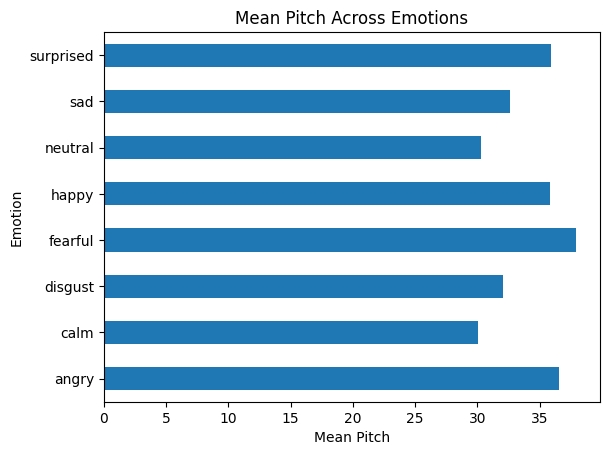

In [39]:
mean_pitch.plot(
    kind="barh"
)

plt.xlabel("Mean Pitch")
plt.ylabel("Emotion")
plt.title("Mean Pitch Across Emotions")
plt.show()

In [40]:
corr = df2.drop(columns=["Emotion"]).corr()

In [41]:
corr

,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
F0semitoneFrom27.5Hz_sma3nz_amean,1.000000,-0.233286,0.976979,0.990913,0.978894,0.152624,-0.013423,-0.002680,0.115157,0.118163,...,0.416048,0.051505,0.265718,-0.005026,-0.164849,0.312942,0.315646,0.100314,-0.110656,0.599594
F0semitoneFrom27.5Hz_sma3nz_stddevNorm,-0.233286,1.000000,-0.357300,-0.239214,-0.135163,0.543944,0.321689,0.264576,0.242407,0.152318,...,-0.237552,-0.005904,0.130998,0.016221,0.218040,-0.171759,-0.024097,-0.185063,-0.079363,0.054714
F0semitoneFrom27.5Hz_sma3nz_percentile20.0,0.976979,-0.357300,1.000000,0.969685,0.928543,-0.041380,-0.040532,-0.027542,0.075294,0.094157,...,0.405953,0.034556,0.236603,0.000236,-0.188823,0.323279,0.309172,0.120889,-0.097639,0.562152
F0semitoneFrom27.5Hz_sma3nz_percentile50.0,0.990913,-0.239214,0.969685,1.000000,0.973035,0.155387,-0.014427,-0.004186,0.118395,0.119369,...,0.398918,0.048483,0.281591,-0.006725,-0.172900,0.317116,0.311847,0.107456,-0.113939,0.617296
F0semitoneFrom27.5Hz_sma3nz_percentile80.0,0.978894,-0.135163,0.928543,0.973035,1.000000,0.332484,0.009541,0.017461,0.148168,0.139097,...,0.387468,0.063084,0.294357,-0.007678,-0.144767,0.294844,0.312236,0.084679,-0.118260,0.626410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MeanVoicedSegmentLengthSec,0.312942,-0.171759,0.323279,0.317116,0.294844,-0.027735,-0.098819,-0.084048,-0.039935,-0.042318,...,-0.008288,0.058601,-0.031892,-0.158549,-0.777705,1.000000,0.523378,0.550434,-0.226065,0.449574
StddevVoicedSegmentLengthSec,0.315646,-0.024097,0.309172,0.311847,0.312236,0.054915,-0.018181,-0.010600,0.058164,0.061119,...,-0.052753,-0.005753,0.098814,-0.072170,-0.455562,0.523378,1.000000,0.201352,-0.065985,0.456749
MeanUnvoicedSegmentLength,0.100314,-0.185063,0.120889,0.107456,0.084679,-0.079210,-0.184287,-0.159928,-0.101472,-0.094836,...,-0.020027,0.109814,-0.099674,-0.111848,-0.753065,0.550434,0.201352,1.000000,0.148612,0.090278
StddevUnvoicedSegmentLength,-0.110656,-0.079363,-0.097639,-0.113939,-0.118260,-0.070239,-0.078033,-0.083163,-0.056539,-0.048302,...,-0.011207,0.056075,-0.069012,-0.106126,-0.176299,-0.226065,-0.065985,0.148612,1.000000,-0.212713


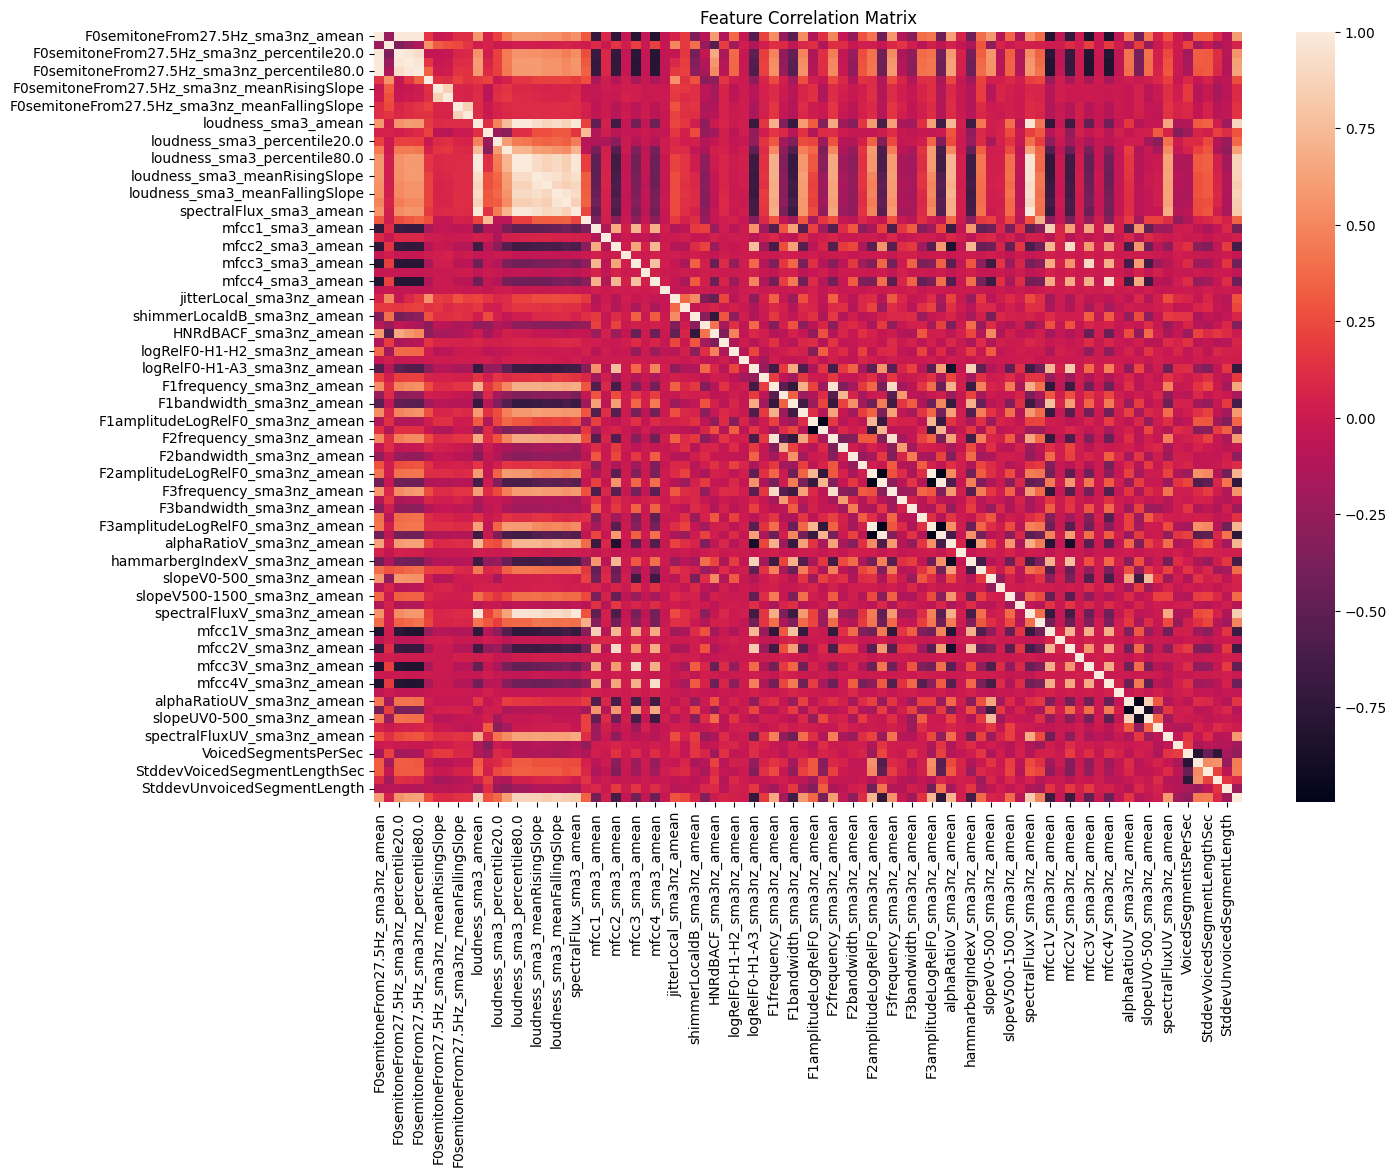

In [42]:
import seaborn as sns


plt.figure(figsize=(14,10))
sns.heatmap(corr)
plt.title("Feature Correlation Matrix")
plt.show()

In [43]:
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]
        if abs(value) > 0.9:
            print(
                corr.columns[i],
                "<->",
                corr.columns[j],
                "=",
                round(value, 3)
            )

F0semitoneFrom27.5Hz_sma3nz_amean <-> F0semitoneFrom27.5Hz_sma3nz_percentile20.0 = 0.977
F0semitoneFrom27.5Hz_sma3nz_amean <-> F0semitoneFrom27.5Hz_sma3nz_percentile50.0 = 0.991
F0semitoneFrom27.5Hz_sma3nz_amean <-> F0semitoneFrom27.5Hz_sma3nz_percentile80.0 = 0.979
F0semitoneFrom27.5Hz_sma3nz_percentile20.0 <-> F0semitoneFrom27.5Hz_sma3nz_percentile50.0 = 0.97
F0semitoneFrom27.5Hz_sma3nz_percentile20.0 <-> F0semitoneFrom27.5Hz_sma3nz_percentile80.0 = 0.929
F0semitoneFrom27.5Hz_sma3nz_percentile50.0 <-> F0semitoneFrom27.5Hz_sma3nz_percentile80.0 = 0.973
loudness_sma3_amean <-> loudness_sma3_percentile80.0 = 0.991
loudness_sma3_amean <-> loudness_sma3_pctlrange0-2 = 0.99
loudness_sma3_amean <-> loudness_sma3_meanRisingSlope = 0.933
loudness_sma3_amean <-> loudness_sma3_meanFallingSlope = 0.92
loudness_sma3_amean <-> spectralFlux_sma3_amean = 0.977
loudness_sma3_amean <-> spectralFluxV_sma3nz_amean = 0.962
loudness_sma3_percentile80.0 <-> loudness_sma3_pctlrange0-2 = 1.0
loudness_sma3_pe

In [44]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    confusion_matrix
)

In [45]:
df3 = pd.read_csv("ravdess_egemaps.csv")

In [46]:
X= df3.drop(columns=["Emotion"])

In [47]:
y= df3["Emotion"]

In [48]:
X.head()

,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,24.263884,0.104171,21.653511,23.907380,27.101028,5.447517,104.436584,113.437210,31.389978,8.258454,...,0.058064,0.011220,0.005713,2.127660,0.925926,0.336667,0.226912,0.540000,0.480260,-47.939644
1,25.167889,0.103561,23.178247,25.003677,27.699860,4.521612,56.695114,18.043581,9.703053,9.479507,...,0.050419,0.012741,0.005434,2.409639,1.223242,0.257500,0.089826,0.535000,0.485206,-47.342330
2,24.186604,0.103495,22.353912,23.728384,27.093287,4.739374,209.152560,255.810780,13.067563,11.153259,...,0.055127,0.014029,0.007729,2.153846,0.630915,0.545000,0.175000,0.676667,0.414836,-45.849762
3,24.268760,0.096042,22.443832,24.478970,26.744179,4.300346,159.005050,128.233870,31.331654,10.120683,...,0.056815,0.012169,0.008324,2.222222,0.977199,0.333333,0.267374,0.500000,0.445702,-46.193146
4,24.898132,0.117897,22.419266,24.678062,28.138033,5.718767,214.876070,234.977680,32.979195,25.259748,...,0.062112,0.010664,0.007934,2.840909,1.440922,0.182000,0.116172,0.408333,0.441717,-50.563885


In [49]:
y.head()

0    neutral
1    neutral
2    neutral
3    neutral
4       calm
Name: Emotion, dtype: object

In [50]:
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [51]:
acc_ = []

uar_ = []

In [52]:
for train_idx, test_idx in skf.split(X, y):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    svm = SVC(
        kernel="rbf",
        C=1
    )

    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    uar = recall_score(
        y_test,
        y_pred,
        average="macro"
    )

    acc_.append(acc)

    uar_.append(uar)

In [53]:
print("Mean Accuracy:", np.mean(acc_))

print("Accuracy Std:", np.std(acc_))

print("Mean UAR:", np.mean(uar_))

print("UAR Std:", np.std(uar_))

Mean Accuracy: 0.7861111111111111
Accuracy Std: 0.015309310892394871
Mean UAR: 0.7731393387314439
UAR Std: 0.01471007266699816


In [54]:
cm = confusion_matrix(y_test, y_pred)
labels = sorted(y.unique())

In [55]:
cm

array([[30,  1,  2,  0,  4,  1,  0,  0],
       [ 0, 36,  0,  0,  0,  2,  0,  0],
       [ 2,  0, 32,  0,  2,  0,  2,  0],
       [ 2,  0,  3, 27,  1,  0,  5,  1],
       [ 2,  2,  1,  2, 27,  2,  2,  1],
       [ 0,  3,  1,  1,  0, 11,  3,  0],
       [ 0,  3,  1,  0,  4,  1, 28,  1],
       [ 0,  0,  1,  1,  1,  1,  1, 34]])

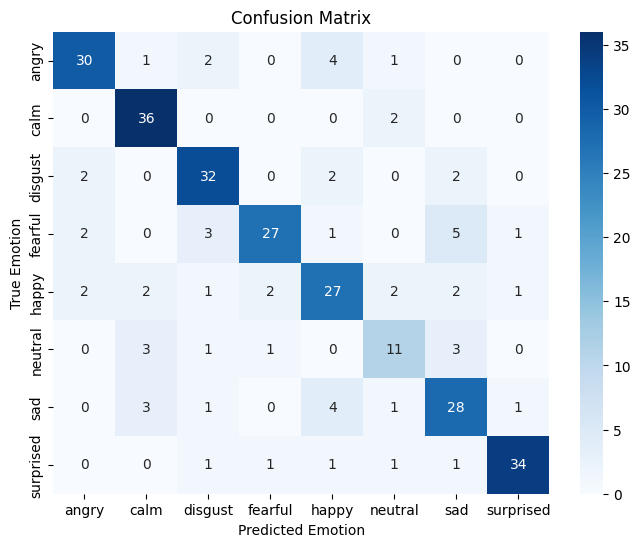

In [56]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, 
    annot=True, 
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Confusion Matrix")
plt.show()

In [57]:
c_values = [0.1, 1, 10]
for c in c_values:
        svm = SVC(
            kernel="rbf",
            C=c
        )
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_test)
        acc = accuracy_score(
            y_test,
            y_pred
        )
        uar = recall_score(
            y_test,
            y_pred,
            average="macro"
        )
        acc_.append(acc)
        uar_.append(uar)
        print("\n=====================")
        print(f"C = {c}")
        print("======================")
        print("Mean Accuracy:",
          np.mean(acc_))
        print("Mean UAR:",
          np.mean(uar_))


C = 0.1
Mean Accuracy: 0.7632575757575757
Mean UAR: 0.7484081707765917

C = 1
Mean Accuracy: 0.7647569444444443
Mean UAR: 0.7501152721547458

C = 10
Mean Accuracy: 0.7799145299145298
Mean UAR: 0.7663137132772759


In [58]:
acc_scores = []

uar_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(
        y_test,
        y_pred
    )
    uar = recall_score(
        y_test,
        y_pred,
        average="macro"
    )
    acc_scores.append(acc)
    uar_scores.append(uar)
print("Mean Accuracy:",
      np.mean(acc_scores))
print("Mean UAR:",
      np.mean(uar_scores))

Mean Accuracy: 0.9638888888888888
Mean UAR: 0.9642695681511471


In [59]:
np.std(acc_scores)

np.float64(0.015774745405000765)

In [60]:
np.std(uar_scores)

np.float64(0.01577193242630206)

In [61]:
importance = rf.feature_importances_

In [62]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [63]:
top20 = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(20)

In [64]:
top20

,Feature,Importance
5,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,0.026704
66,spectralFluxV_sma3nz_amean,0.023583
18,loudness_sma3_meanFallingSlope,0.023506
30,jitterLocal_sma3nz_amean,0.020851
15,loudness_sma3_pctlrange0-2,0.019946
14,loudness_sma3_percentile80.0,0.018748
1,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,0.018174
16,loudness_sma3_meanRisingSlope,0.017676
20,spectralFlux_sma3_amean,0.017234
13,loudness_sma3_percentile50.0,0.016547


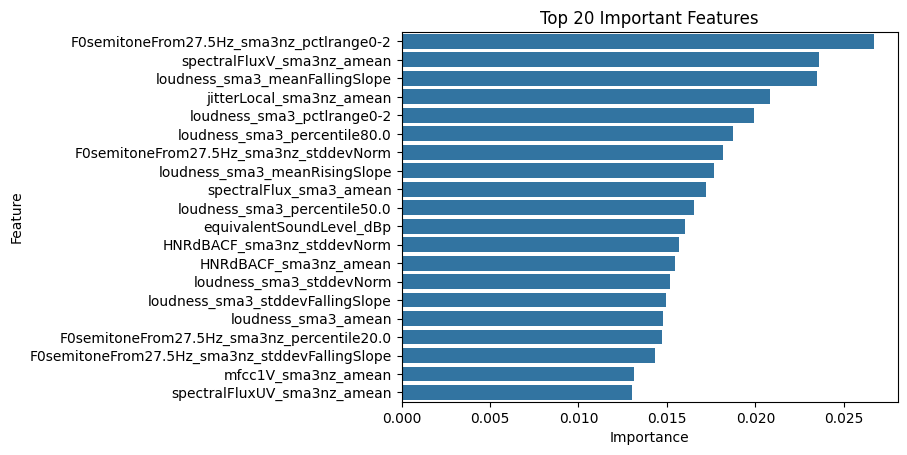

In [65]:
sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.show()

In [66]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [67]:
import umap

In [68]:


df4 = pd.read_csv ("ravdess_egemaps.csv")
X = df4 . drop ("Emotion", axis =1) . values
y = df4 ["Emotion"]. values

reducer = umap . UMAP ( n_neighbors =15 , min_dist =0.1 , random_state
=42)
embedding = reducer . fit_transform ( X )

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


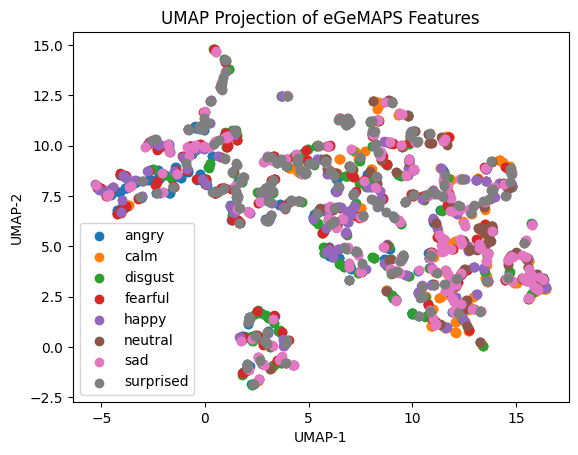

In [69]:
for emotion in np.unique(y):
    idx = y == emotion
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        label=emotion
    )

plt.title("UMAP Projection of eGeMAPS Features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.show()

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


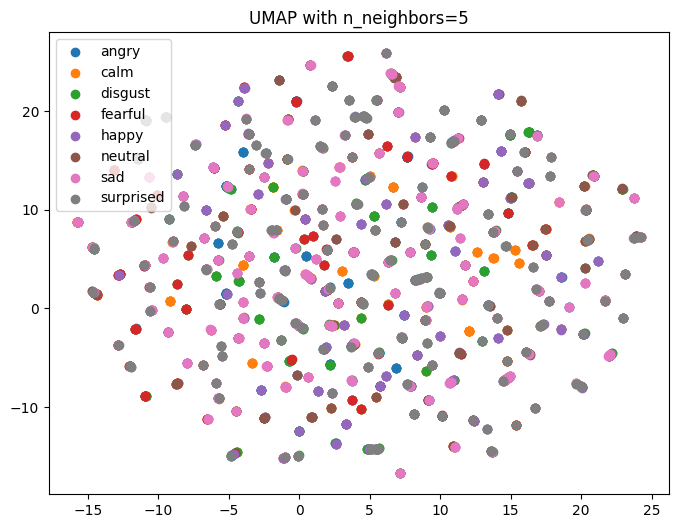

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


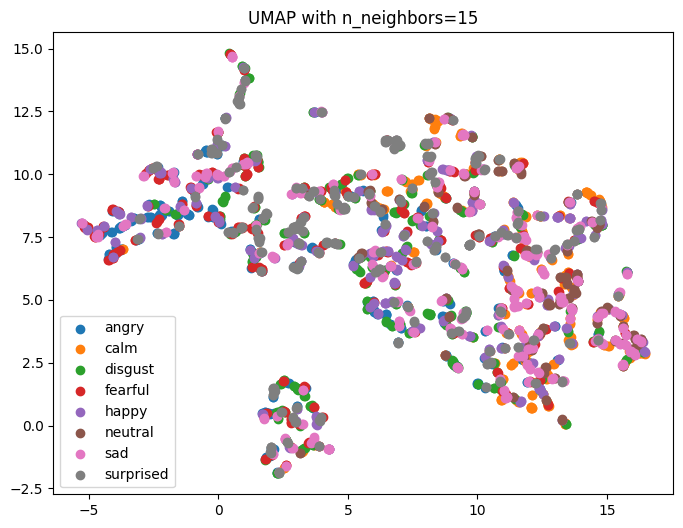

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


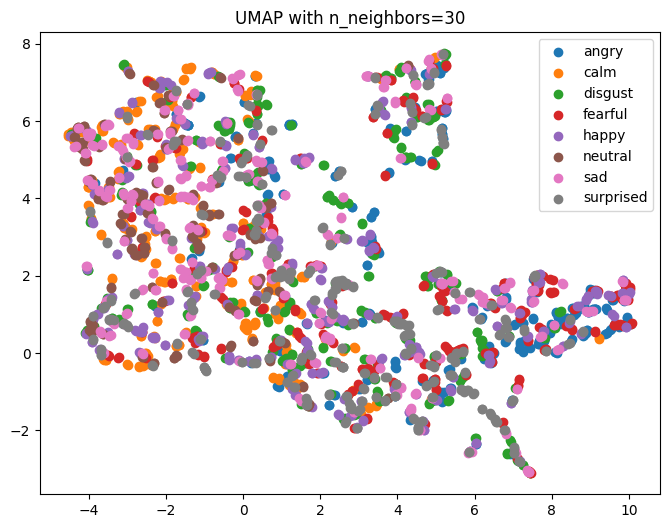

In [70]:
neighbors = [5, 15, 30]

for n in neighbors:
    reducer = umap.UMAP(
        n_neighbors=n,
        min_dist=0.1,
        random_state=42
    )
    embedding = reducer.fit_transform(X)

    plt.figure(figsize=(8,6))
    for emotion in np.unique(y):
        idx = y == emotion
        plt.scatter(
            embedding[idx, 0],
            embedding[idx, 1],
            label=emotion
        )

    plt.title(f"UMAP with n_neighbors={n}")
    plt.legend()
    plt.show()

In [71]:
X_scaled = scaler.fit_transform(X)

In [72]:
embedding_scaled = reducer.fit_transform(X_scaled)

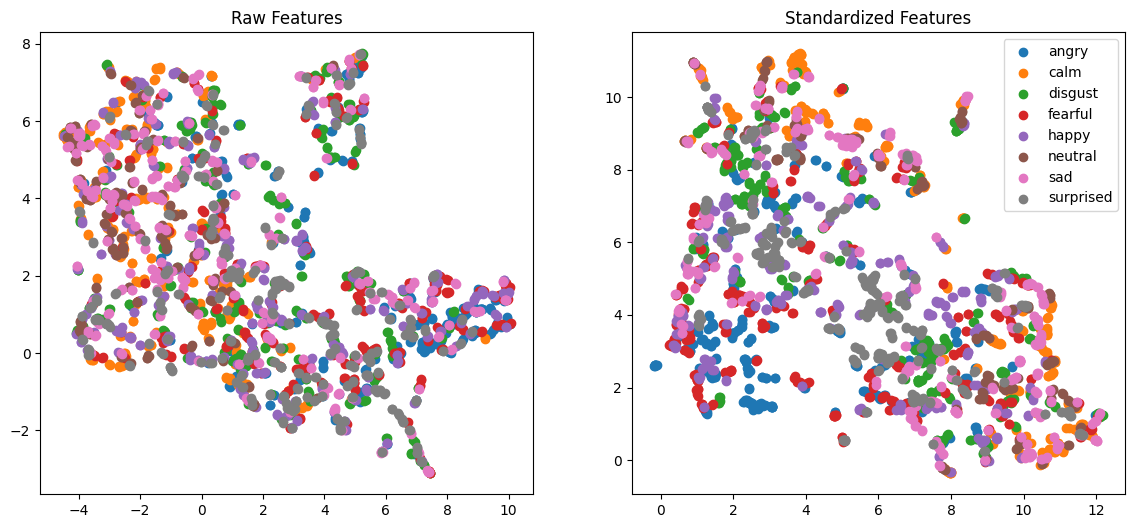

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for emotion in np.unique(y):
    idx = y == emotion
    axes[0].scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        label=emotion
    )
axes[0].set_title("Raw Features")

for emotion in np.unique(y):
    idx = y == emotion
    axes[1].scatter(
        embedding_scaled[idx, 0],
        embedding_scaled[idx, 1],
        label=emotion
    )
axes[1].set_title("Standardized Features")
axes[1].legend()

plt.show()

In [74]:
pip install torch torchaudio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [75]:
import torch
import torchaudio
from torch.utils.data import Dataset

In [76]:
class RavdessDataset(Dataset):

    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=22050,
            n_mels=64
        )

        self.db_transform = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]
        label = self.labels[idx]

        audio, sr = librosa.load(  
            file,
            sr=22050
        )
        waveform = torch.tensor(audio).unsqueeze(0)

        mel = self.mel_transform(waveform)

        mel = self.db_transform(mel)

        mel = (mel - mel.mean()) / mel.std()

        mel = mel.squeeze(0)

        if mel.shape[1] < 128:
            pad = 128 - mel.shape[1]
            mel = torch.nn.functional.pad(
                mel,
                (0, pad)
            )
        else:
            mel = mel[:, :128]

        return mel.unsqueeze(0), label

In [77]:
emotion_to_idx = {
    emotion: i
    for i, emotion in enumerate(df["Emotion"].unique())
}

In [78]:
labels = [
    emotion_to_idx[
        parse_ravdess_filename(f)["Emotion"]
    ]
    for f in wav_files
]

In [79]:
from sklearn.model_selection import train_test_split
train_files, test_files, train_labels, test_labels = train_test_split(
    wav_files,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [80]:
train_dataset = RavdessDataset(
    train_files,
    train_labels
)

test_dataset = RavdessDataset(
    test_files,
    test_labels
)

In [81]:
len(train_dataset)

2304

In [82]:
len(test_dataset)

576

In [83]:
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Linear(
            256,
            num_classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [84]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [85]:
model = CNN(
    num_classes=len(emotion_to_idx)
)

In [86]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total Parameters:", total_params)

Total Parameters: 299272


In [87]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [88]:
import time

In [89]:
train_losses = []
val_losses = []

for epoch in range(20):
    epoch_start = time.time()
    model.train()
    running_loss = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()

    running_val_loss = 0


    with torch.no_grad():

        for x, y in test_loader:
            outputs = model(x)
            
            loss = criterion(outputs, y)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(test_loader)
    val_losses.append(val_loss)
    epoch_end = time.time()
    epoch_time = epoch_end - epoch_start
    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Time: {epoch_time:.2f} sec"
    )

Epoch 1/20 | Train Loss: 1.9962 | Val Loss: 1.9589 | Time: 55.62 sec
Epoch 2/20 | Train Loss: 1.9414 | Val Loss: 1.9403 | Time: 55.08 sec
Epoch 3/20 | Train Loss: 1.9085 | Val Loss: 1.9342 | Time: 55.45 sec
Epoch 4/20 | Train Loss: 1.8817 | Val Loss: 1.8950 | Time: 55.05 sec
Epoch 5/20 | Train Loss: 1.8648 | Val Loss: 1.8550 | Time: 55.25 sec
Epoch 6/20 | Train Loss: 1.8610 | Val Loss: 1.9065 | Time: 55.73 sec
Epoch 7/20 | Train Loss: 1.8445 | Val Loss: 1.8406 | Time: 55.39 sec
Epoch 8/20 | Train Loss: 1.8265 | Val Loss: 1.8515 | Time: 56.01 sec
Epoch 9/20 | Train Loss: 1.8166 | Val Loss: 1.8697 | Time: 55.65 sec
Epoch 10/20 | Train Loss: 1.7929 | Val Loss: 2.0874 | Time: 54.99 sec
Epoch 11/20 | Train Loss: 1.7961 | Val Loss: 1.8608 | Time: 54.95 sec
Epoch 12/20 | Train Loss: 1.7973 | Val Loss: 1.8083 | Time: 55.55 sec
Epoch 13/20 | Train Loss: 1.7777 | Val Loss: 1.8280 | Time: 55.18 sec
Epoch 14/20 | Train Loss: 1.7702 | Val Loss: 1.8266 | Time: 55.42 sec
Epoch 15/20 | Train Loss: 1.7

In [90]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = model(x)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_true.extend(y.numpy())

In [91]:
acc = accuracy_score(
    all_true,
    all_preds
)

uar = recall_score(
    all_true,
    all_preds,
    average="macro"
)

In [94]:
acc

0.25

In [95]:
uar

0.23391575529733422

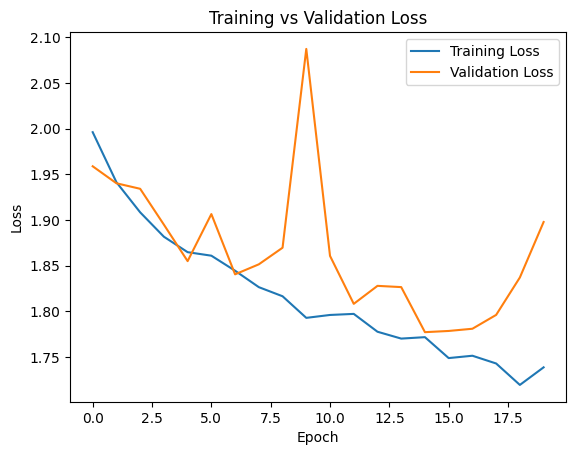

In [96]:
plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()